In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [2]:
df = pd.read_csv("../Data/Cleaned_data/Clean.csv")
df = df.set_index("Date_month")
df.index = pd.to_datetime(df.index) #Sets my date index to specifically be date data type
df

,SP500_monthly_return,SP500_volatility,YOY_inflation,Inflation_volatility,Inflation_surprise,Inflation_lag,Volatility_lag,Surprise_lag
Date_month,,,,,,,,
2001-01-01,-2.429990,4.567131,3.721205,0.239086,0.721205,3.436019,0.286482,0.636019
2001-02-01,7.028914,5.041273,3.529412,0.229091,0.729412,3.721205,0.239086,0.721205
2001-03-01,-9.628168,5.732928,2.982456,0.248253,0.182456,3.529412,0.229091,0.729412
2001-04-01,-7.682701,5.115852,3.218256,0.224944,0.118256,2.982456,0.248253,0.182456
2001-05-01,10.522131,6.279052,3.563084,0.208416,0.363084,3.218256,0.224944,0.118256
...,...,...,...,...,...,...,...,...
2025-08-01,0.645368,3.235395,2.938592,0.232003,-1.861408,2.742618,0.213919,-1.757382
2025-09-01,2.845944,3.270414,3.022572,0.242695,-1.677428,2.938592,0.232003,-1.861408
2025-10-01,4.608500,3.366205,2.858718,0.243175,-1.741282,3.022572,0.242695,-1.677428


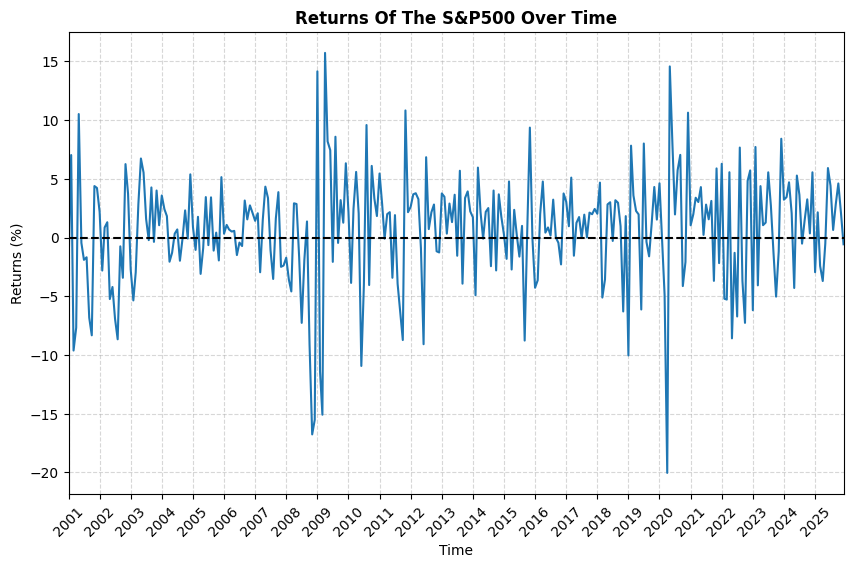

In [3]:
#This code plots a monthly time series of the S&P500 return from the start of 2001 to the end of 2025
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.SP500_monthly_return)
plt.axhline(0, color="black", linestyle="dashed") #Produces a dotted line at 0
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1)) #Sets x axis ticks to be every year
plt.xticks(rotation=45)
plt.title("Returns Of The S&P500 Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Returns (%)")
plt.grid(linestyle="--",alpha=0.5)

<Figure size 1000x600 with 0 Axes>

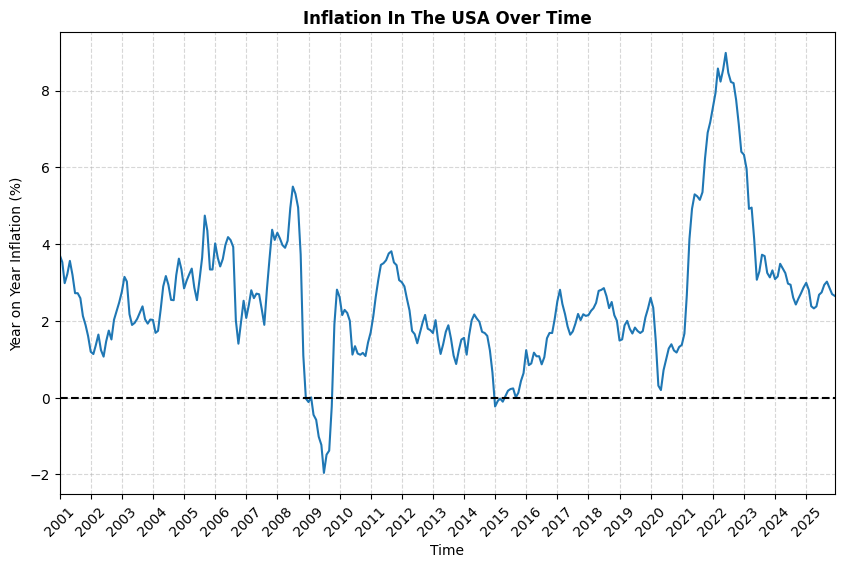

In [4]:
#Time series for inflation
plt.figure(figsize=(10,6))
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.YOY_inflation)
plt.axhline(0, color="black", linestyle="dashed")
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Year on Year Inflation (%)")
plt.grid(linestyle="--",alpha=0.5)

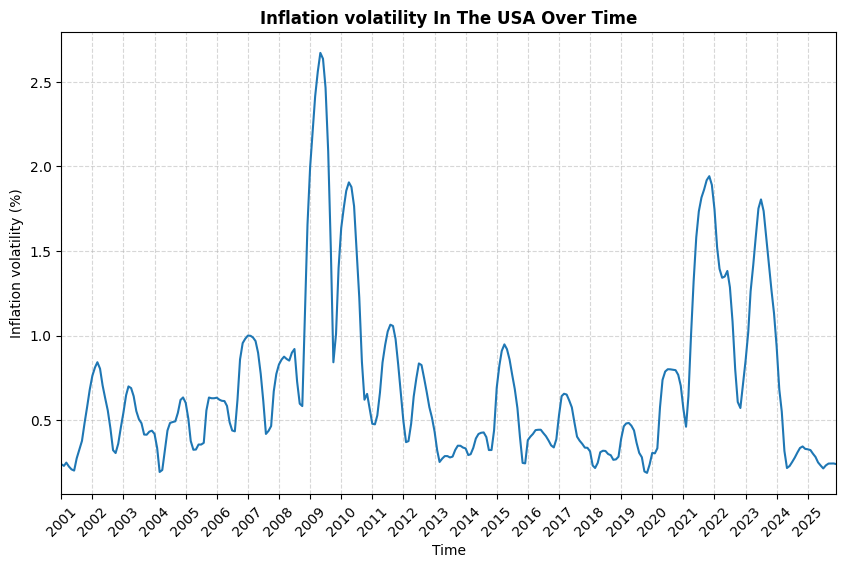

In [5]:
#Time series for inflation volatility
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.Inflation_volatility)
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation volatility In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Inflation volatility (%)")
plt.grid(linestyle="--",alpha=0.5)

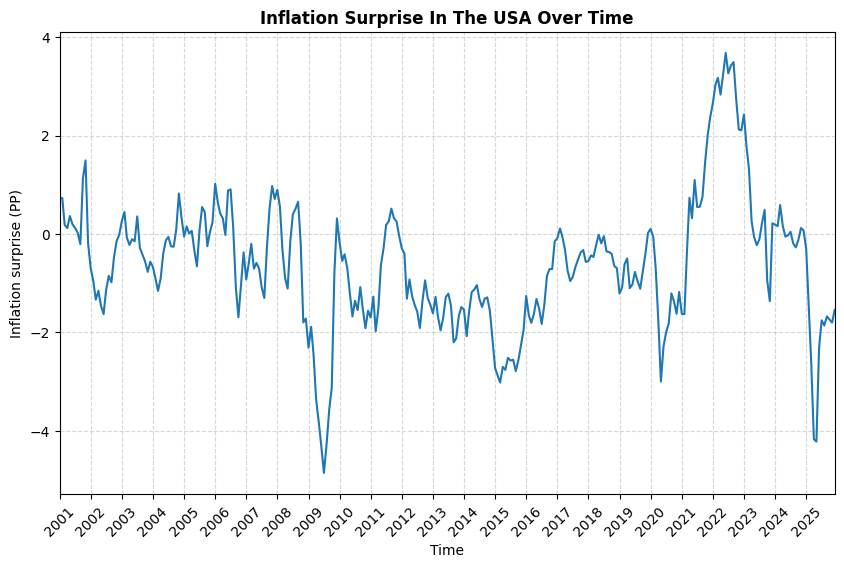

In [6]:
#Time series of inflation surprise over time (the difference between actual inflation and expected inflation)
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.Inflation_surprise)
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation Surprise In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Inflation surprise (PP)")
plt.grid(linestyle="--",alpha=0.5)

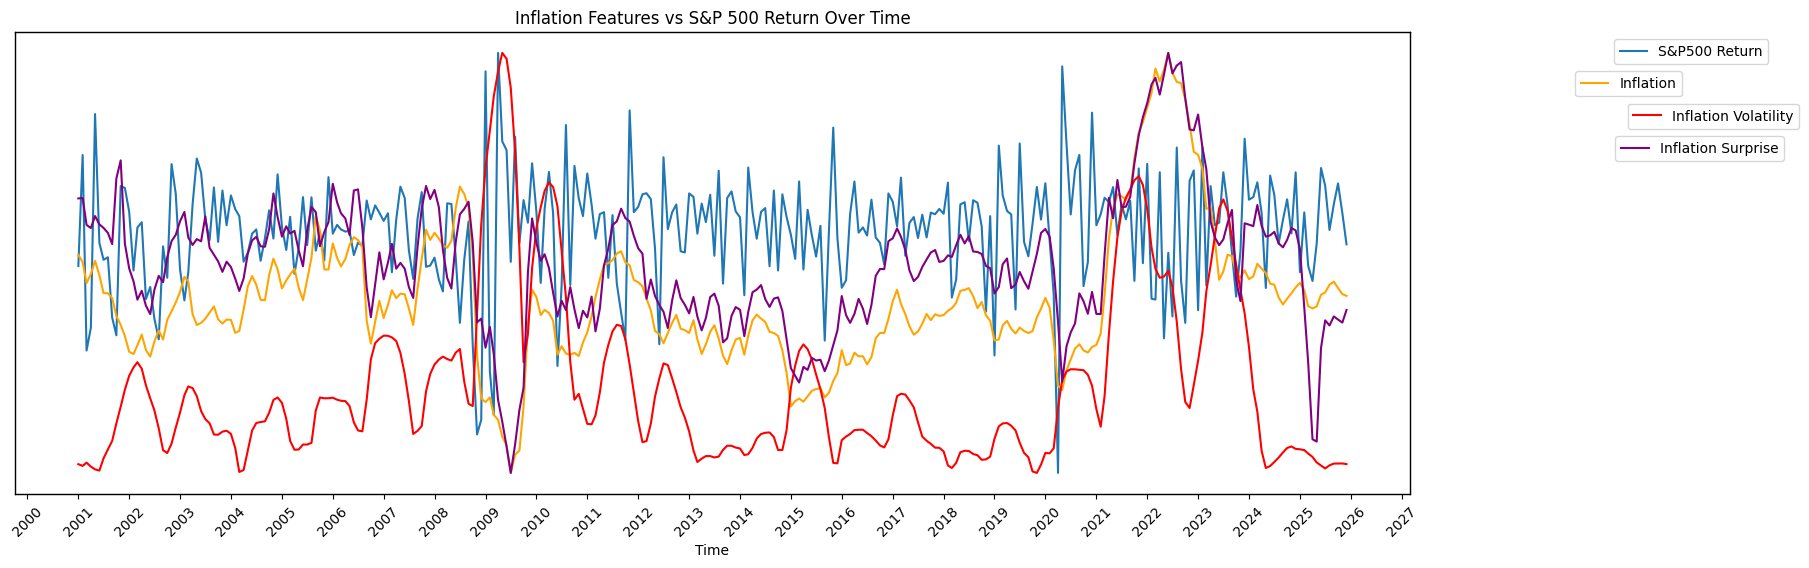

In [7]:
#Time series comparing all previously mentioned components of inflation over time on a monthly basis
plt.figure(figsize=(18,6))
ax1 = sns.lineplot(x=df.index, y=df.SP500_monthly_return, label = "S&P500 Return")
ax1.grid(False)
ax1.set_ylabel("")
ax1.set_yticks([])
ax2 = ax1.twinx()
sns.lineplot(x=df.index, y=df.YOY_inflation, ax=ax2, color="orange", label = "Inflation")
ax2.grid(False)
ax2.set_ylabel("")
ax2.set_yticks([])
ax3 = ax2.twinx()
sns.lineplot(x=df.index, y=df.Inflation_volatility, ax=ax3, color="red", label = "Inflation Volatility")
ax3.grid(False)
ax3.set_ylabel("")
ax3.set_yticks([])
ax4 = ax3.twinx()
sns.lineplot(x=df.index, y=df.Inflation_surprise, ax=ax4, color="purple", label = "Inflation Surprise")
ax4.grid(False)
ax4.set_ylabel("")
ax4.set_yticks([])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Time")
plt.title("Inflation Features vs S&P 500 Return Over Time")
ax1.legend(bbox_to_anchor=(1.262, 1))
ax2.legend(bbox_to_anchor=(1.2, 0.93))
ax3.legend(bbox_to_anchor=(1.284, 0.86))
ax4.legend(bbox_to_anchor=(1.273, 0.79))
plt.show()


<Figure size 1800x600 with 0 Axes>

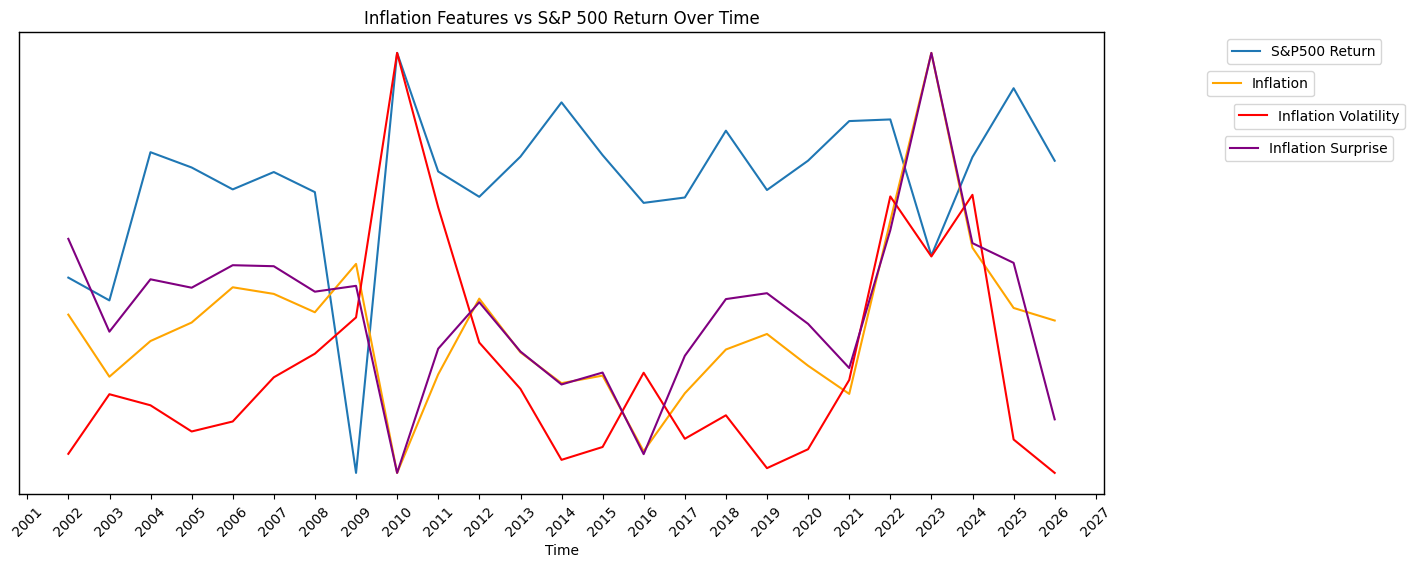

In [8]:
#Time series comparing all previously mentioned components of inflation over time on a yearly basis
plt.figure(figsize=(18,6))
df_yearly = df.resample('YE').mean() #Decided to resample data to yearly data points since monthly values made the graph very cluttered
plt.figure(figsize=(14,6))
ax1 = sns.lineplot(x=df_yearly.index, y=df_yearly.SP500_monthly_return, label = "S&P500 Return")
ax1.grid(False) #removes grid lines
ax1.set_ylabel("") #removes y axis label
ax1.set_yticks([]) #removes y tick names
ax2 = ax1.twinx() #allows me to add another y axis
sns.lineplot(x=df_yearly.index, y=df_yearly.YOY_inflation, ax=ax2, color="orange", label = "Inflation")
ax2.grid(False)
ax2.set_ylabel("")
ax2.set_yticks([])
ax3 = ax2.twinx()
sns.lineplot(x=df_yearly.index, y=df_yearly.Inflation_volatility, ax=ax3, color="red", label = "Inflation Volatility")
ax3.grid(False)
ax3.set_ylabel("")
ax3.set_yticks([])
ax4 = ax3.twinx()
sns.lineplot(x=df_yearly.index, y=df_yearly.Inflation_surprise, ax=ax4, color="purple", label = "Inflation Surprise")
ax4.grid(False)
ax4.set_ylabel("")
ax4.set_yticks([])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1)) #changes x axis ticks to every year
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Time")
plt.title("Inflation Features vs S&P 500 Return Over Time")
ax1.legend(bbox_to_anchor=(1.262, 1)) #positions the legend in a different place
ax2.legend(bbox_to_anchor=(1.2, 0.93))
ax3.legend(bbox_to_anchor=(1.284, 0.86))
ax4.legend(bbox_to_anchor=(1.273, 0.79))
plt.show()


P value: 0.23397878475624345
R Value: -0.06892059990226282
R Squared Value: 0.00475004909088779


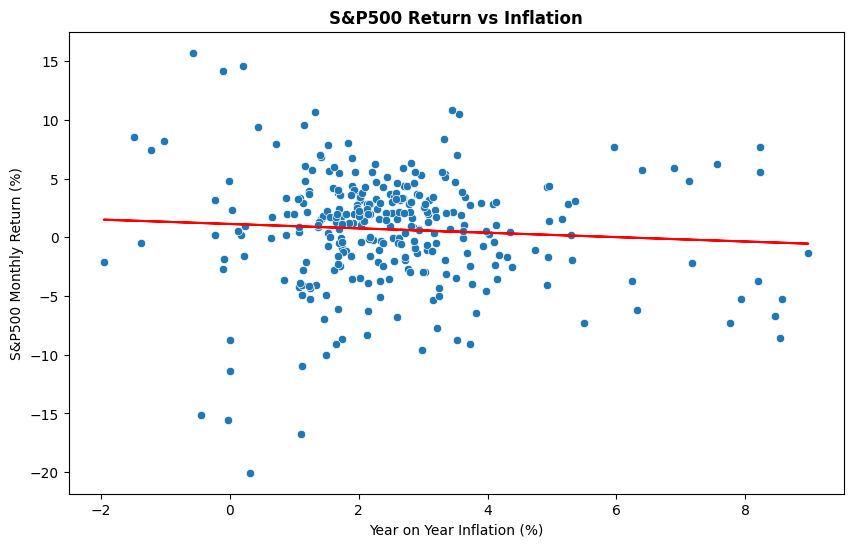

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.YOY_inflation, y=df.SP500_monthly_return)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.YOY_inflation, y=df.SP500_monthly_return)
plt.plot(df.YOY_inflation, slope * df.YOY_inflation + intercept, color="red")
plt.title("S&P500 Return vs Inflation", weight="bold")
plt.xlabel("Year on Year Inflation (%)")
plt.ylabel("S&P500 Monthly Return (%)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 0.9991787784331346
R Value: 5.967282099866619e-05
R Squared Value: 3.5608455659388564e-09


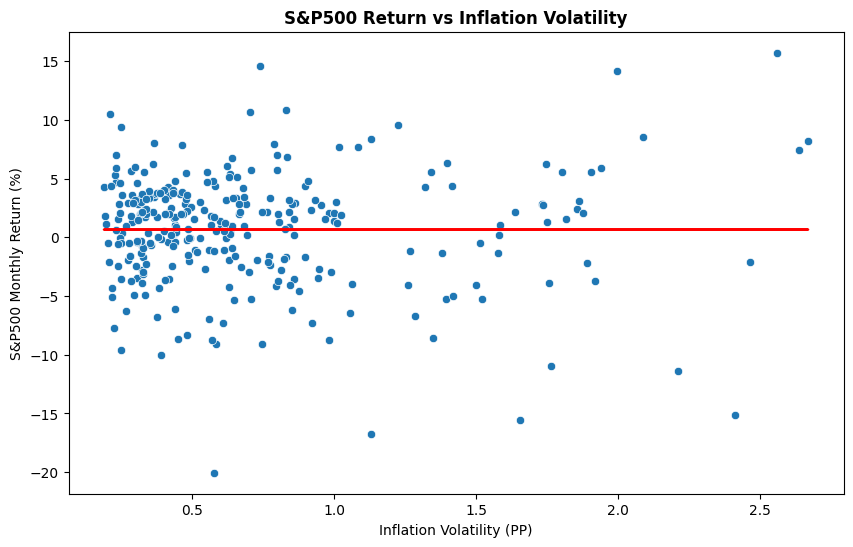

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Inflation_volatility, y=df.SP500_monthly_return)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_volatility, y=df.SP500_monthly_return)
plt.plot(df.Inflation_volatility, slope * df.Inflation_volatility + intercept, color="red")
plt.title("S&P500 Return vs Inflation Volatility", weight="bold")
plt.xlabel("Inflation Volatility (PP)")
plt.ylabel("S&P500 Monthly Return (%)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 0.14448432012952442
R Value: -0.08445433519730161
R Squared Value: 0.007132534733618178


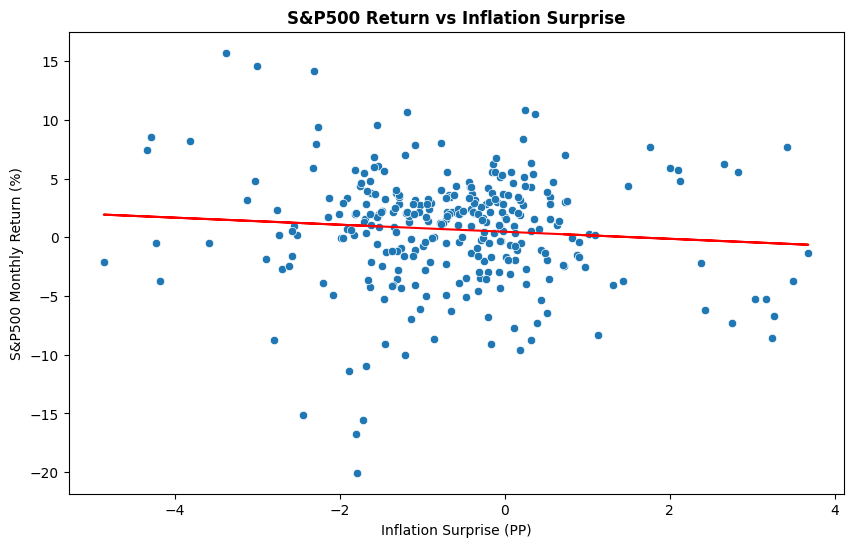

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Inflation_surprise, y=df.SP500_monthly_return)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_surprise, y=df.SP500_monthly_return)
plt.plot(df.Inflation_surprise, slope * df.Inflation_surprise + intercept, color="red")
plt.title("S&P500 Return vs Inflation Surprise", weight="bold")
plt.xlabel("Inflation Surprise (PP)")
plt.ylabel("S&P500 Monthly Return (%)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 7.186488098294385e-06
R Value: -0.25586208702537694
R Squared Value: 0.06546540757698156


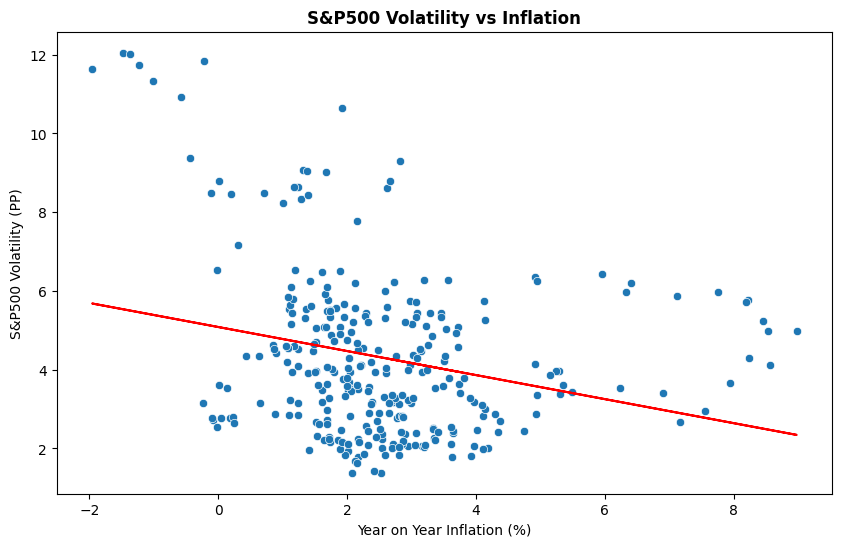

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.YOY_inflation, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.YOY_inflation, y=df.SP500_volatility)
plt.plot(df.YOY_inflation, slope * df.YOY_inflation + intercept, color="red")
plt.title("S&P500 Volatility vs Inflation", weight="bold")
plt.ylabel("S&P500 Volatility (PP)")
plt.xlabel("Year on Year Inflation (%)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 5.831009716507495e-17
R Value: 0.4579780013714574
R Squared Value: 0.20974384974019464


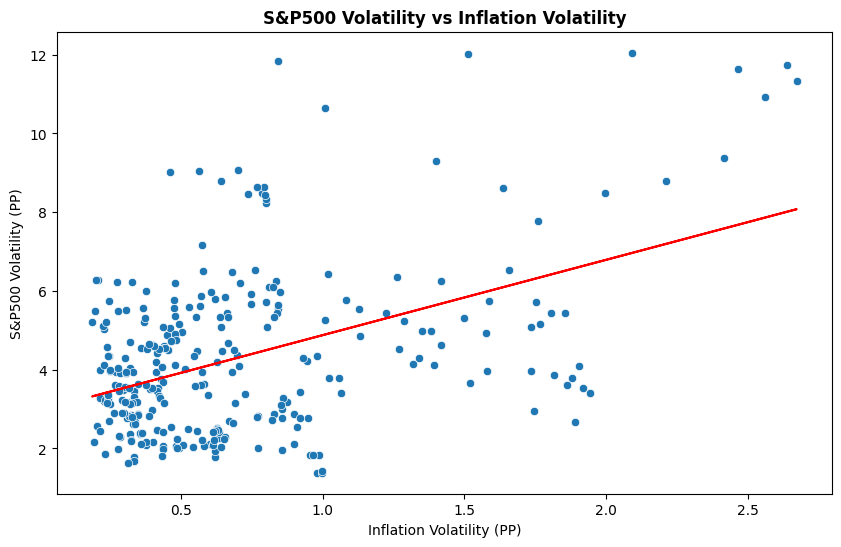

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Inflation_volatility, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_volatility, y=df.SP500_volatility)
plt.plot(df.Inflation_volatility, slope * df.Inflation_volatility + intercept, color="red")
plt.title("S&P500 Volatility vs Inflation Volatility", weight="bold")
plt.ylabel("S&P500 Volatility (PP)")
plt.xlabel("Inflation Volatility (PP)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 2.0287410942608322e-05
R Value: -0.2433565753699523
R Squared Value: 0.05922242277579128


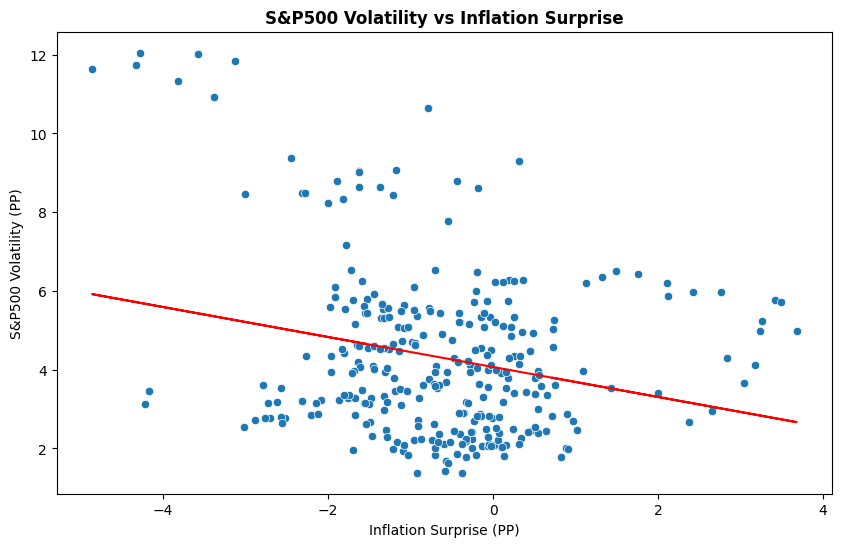

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Inflation_surprise, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_surprise, y=df.SP500_volatility)
plt.plot(df.Inflation_surprise, slope * df.Inflation_surprise + intercept, color="red")
plt.title("S&P500 Volatility vs Inflation Surprise", weight="bold")
plt.ylabel("S&P500 Volatility (PP)")
plt.xlabel("Inflation Surprise (PP)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

In [15]:
x = df[["YOY_inflation", "Inflation_volatility", "Inflation_surprise"]]
y = df["SP500_monthly_return"]

x = sm.add_constant(x)
model1 = sm.OLS(y, x).fit()

print(model1.summary())

                             OLS Regression Results                             
Dep. Variable:     SP500_monthly_return   R-squared:                       0.007
Model:                              OLS   Adj. R-squared:                 -0.003
Method:                   Least Squares   F-statistic:                    0.7271
Date:                  Thu, 16 Apr 2026   Prob (F-statistic):              0.537
Time:                          14:54:26   Log-Likelihood:                -892.12
No. Observations:                   300   AIC:                             1792.
Df Residuals:                       296   BIC:                             1807.
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [16]:

x = df[["Inflation_lag", "Volatility_lag", "Surprise_lag"]]
y = df["SP500_monthly_return"]

x = sm.add_constant(x)
model2 = sm.OLS(y, x).fit()

print(model2.summary())



                             OLS Regression Results                             
Dep. Variable:     SP500_monthly_return   R-squared:                       0.021
Model:                              OLS   Adj. R-squared:                  0.011
Method:                   Least Squares   F-statistic:                     2.087
Date:                  Thu, 16 Apr 2026   Prob (F-statistic):              0.102
Time:                          14:54:26   Log-Likelihood:                -890.08
No. Observations:                   300   AIC:                             1788.
Df Residuals:                       296   BIC:                             1803.
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.921

In [17]:
x = df[["YOY_inflation", "Inflation_volatility", "Inflation_surprise"]]
y = df["SP500_volatility"]

x = sm.add_constant(x)
model3 = sm.OLS(y, x).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:       SP500_volatility   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     43.48
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.62e-23
Time:                        14:54:26   Log-Likelihood:                -592.12
No. Observations:                 300   AIC:                             1192.
Df Residuals:                     296   BIC:                             1207.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.0814 

In [18]:
x = df[["Inflation_lag", "Volatility_lag", "Surprise_lag"]]
y = df["SP500_volatility"]

x = sm.add_constant(x)
model4 = sm.OLS(y, x).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:       SP500_volatility   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     43.93
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.64e-23
Time:                        14:54:26   Log-Likelihood:                -591.65
No. Observations:                 300   AIC:                             1191.
Df Residuals:                     296   BIC:                             1206.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              4.0724      0.434      9.